In [132]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [133]:
df = pd.read_csv('../datasets/house_prices_dataset.csv')

In [134]:
df.shape

(10000, 5)

In [135]:
df.head()

,square_feet,num_rooms,age,distance_to_city(km),price
0,2248.357077,3,92,22.997972,200374.090410
1,1930.867849,2,22,13.984254,268784.847337
2,2323.844269,6,33,21.500945,315020.857676
3,2761.514928,3,63,10.343638,355111.468459
4,1882.923313,7,54,25.485200,234197.123903


In [136]:
df.isnull().sum()

square_feet             0
num_rooms               0
age                     0
distance_to_city(km)    0
price                   0
dtype: int64

In [137]:
df_skew = df.select_dtypes(include='number').copy()
df_skew.skew()

square_feet             0.014784
num_rooms               0.007929
age                     0.001240
distance_to_city(km)    0.016093
price                   0.008568
dtype: float64

In [138]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   square_feet           10000 non-null  float64
 1   num_rooms             10000 non-null  int64  
 2   age                   10000 non-null  int64  
 3   distance_to_city(km)  10000 non-null  float64
 4   price                 10000 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 390.8 KB


In [139]:
df.describe()

,square_feet,num_rooms,age,distance_to_city(km),price
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1999.147496,4.49510,49.516900,15.362148,263011.571609
std,501.021194,1.71116,28.992336,8.325101,98336.945117
min,500.000000,2.00000,0.000000,1.000161,-95613.138249
25%,1663.704735,3.00000,24.000000,8.121636,196791.510684
50%,1998.702512,4.00000,49.000000,15.403146,262497.361236
75%,2335.540444,6.00000,75.000000,22.447530,330445.581908
max,3963.118853,7.00000,99.000000,29.993892,660168.255648


In [140]:
df_dup = df[df.duplicated()]
df_dup.head(10)

,square_feet,num_rooms,age,distance_to_city(km),price


In [141]:
# Drop the rows where price is less than 0

df = df[df['price'] > 0]

print(f"New Shape: {df.shape}")

New Shape: (9962, 5)


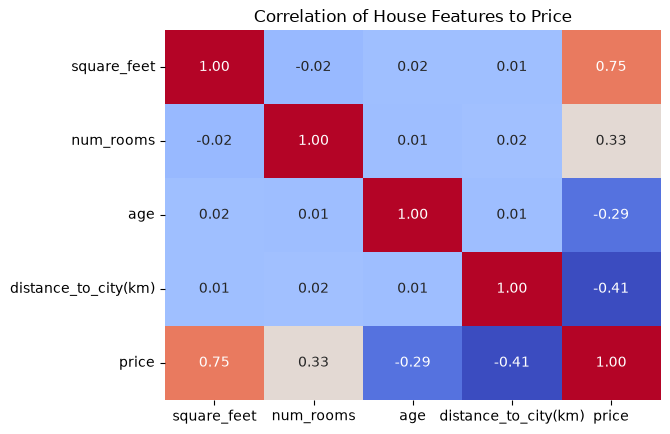

In [142]:
# Feature heatmap 

_corr = df.corr()

sns.heatmap(data=_corr, annot=True, fmt='.2f', cmap='coolwarm', cbar=False)
plt.title('Correlation of House Features to Price')
plt.show()

In [143]:
# Extract target and data

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [144]:
# Split into training and testing

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [145]:
# Scale the dataset 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [146]:
# Make the ANN Class

class HousePredictor(nn.Module):
    def __init__(self):
        super(HousePredictor, self).__init__()

        self.fc1 = nn.Linear(X.shape[1], 64)
        self.fc2 = nn.Linear(64, 32) 
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 1)

    def forward(self, x):
        relu = F.relu

        x = relu(self.fc1(x))
        x = relu(self.fc2(x))
        x = relu(self.fc3(x))
        x = self.fc4(x)

        return x

In [147]:
# Define the data

X_train_tensor = torch.from_numpy(X_train_scaled).float()
X_test_tensor = torch.from_numpy(X_test_scaled).float()

y_train_tensor = torch.from_numpy(y_train).float().unsqueeze(1)
y_test_tensor = torch.from_numpy(y_test).float().unsqueeze(1)

In [148]:
# Make the loader

from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=32)

In [149]:
# Define the model

model = HousePredictor()

In [150]:
# Define the loss

criterion = nn.MSELoss()

In [151]:
# Define the training function

def train_model(model, loader, criterion, optimizer, epochs):
    for _ in range(epochs):
        model.train()

        for x_batch, y_batch in loader:
            optimizer.zero_grad()
            y_pred = model(x_batch)

            loss = criterion(y_pred, y_batch)

            loss.backward()
            optimizer.step()

In [152]:
# Basic optimization 

models = [HousePredictor() for _ in range(3)]
epochs = [10, 50, 100]
trained_models = []

for m, e in zip(models, epochs):
    optimizer_m = optim.Adam(m.parameters(), lr=0.001)
    train_model(m, train_loader, criterion, optimizer_m, e)

    trained_models.append(m)

In [153]:
from sklearn.metrics import root_mean_squared_error as rmse

rmse_arr = []

for t in trained_models:
    t.eval()
    with torch.no_grad():
        y_pred = t(X_test_tensor)
    y_pred_np = y_pred.numpy()

    rmse_arr.append(rmse(y_test, y_pred_np))

best_idx = np.argmin(rmse_arr)
best_model = trained_models[best_idx]
best_model

HousePredictor(
  (fc1): Linear(in_features=4, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=16, bias=True)
  (fc4): Linear(in_features=16, out_features=1, bias=True)
)

In [154]:
# Store the RMSE for the ANN

ann_rmse = rmse_arr[best_idx]

In [155]:
# Store the predicted values for the model

with torch.no_grad():
    y_pred_ann = best_model(X_test_tensor).numpy()

In [156]:
# Test two more standard regression models 

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

lr = LinearRegression()
rf = RandomForestRegressor()

In [157]:
# Do slight hyperparameter tuning

from sklearn.model_selection import GridSearchCV

lr_params = {
    "fit_intercept": [True, False]
}

lr_grid = GridSearchCV(
    estimator=LinearRegression(),
    param_grid=lr_params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=rf_params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

In [158]:
# Train both of them

lr.fit(X_train_scaled, y_train)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numb

In [159]:
# Test both of them and record the RMSEs

y_pred_lr = lr.predict(X_test_scaled) 
y_pred_rf = rf.predict(X_test)

lr_rmse = rmse(y_test, y_pred_lr)
rf_rmse = rmse(y_test, y_pred_rf)

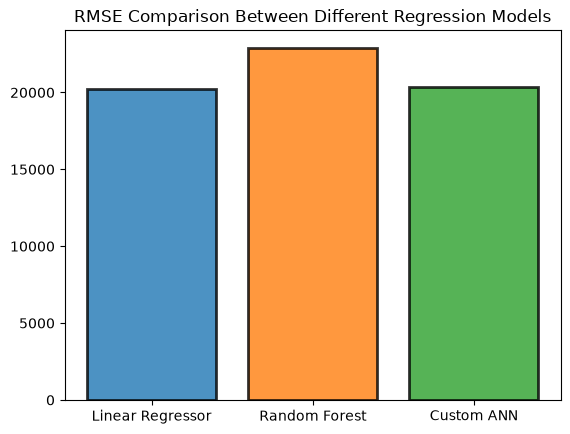

In [160]:
# Plot the RMSEs see which is the most optimal for this dataset 

from matplotlib.colors import TABLEAU_COLORS

tab_colors = list(TABLEAU_COLORS.values())

labels = ['Linear Regressor', 'Random Forest', 'Custom ANN']
data = [lr_rmse, rf_rmse, ann_rmse]

plt.bar(labels, data, color=tab_colors, edgecolor='black', linewidth=2, alpha=0.8)
plt.title('RMSE Comparison Between Different Regression Models')
plt.show()

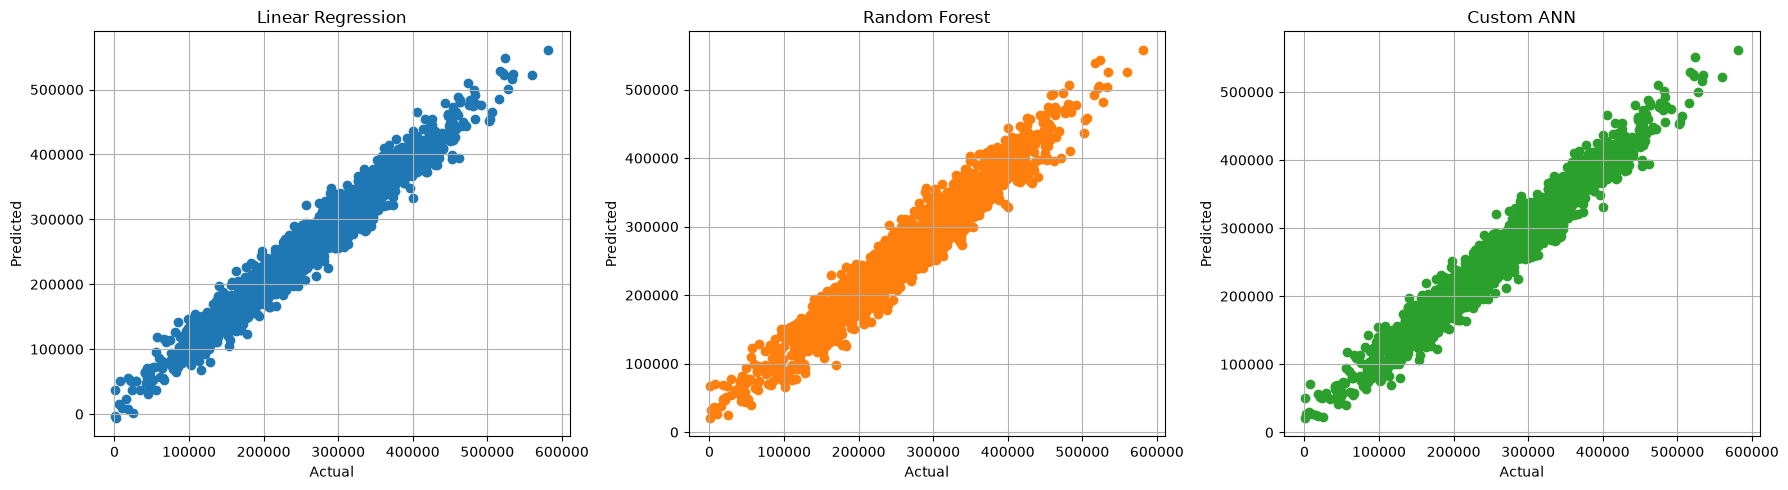

In [161]:
# Plot the predicted vs actual for all models

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].scatter(y_test, y_pred_lr, color=tab_colors[0])
ax[0].set_title("Linear Regression")

ax[1].scatter(y_test, y_pred_rf, color=tab_colors[1])
ax[1].set_title("Random Forest")

ax[2].scatter(y_test, y_pred_ann, color=tab_colors[2])
ax[2].set_title("Custom ANN")

for a in ax:
    a.set_xlabel("Actual")
    a.set_ylabel("Predicted")
    a.grid(True)

plt.tight_layout()
plt.show()